# Exploratory data analysis of the dataset Adult dataset

## Imports and other setup

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt

from ydata_profiling import ProfileReport

In [2]:
os.chdir('..')

In [3]:
DATA_FOLDER = Path('./data')
OUTPUT_FOLDER = Path('./generated/eda')

NAN_SYMBOLE = '?'

## Import dataset

In [ ]:
from tools.utils import load_adults
# target: income
# missing values in workclass, occupation and native country

adults, numerical_columns, categorical_columns = load_adults(DATA_FOLDER/'adult.csv')
adults.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Profiling report
The profiling report is practical to get a quick overview of the dataset distributions and correlation, in a pretty HTML format.
🟠 The number of missing values generated in the report is not correct. See below for the correct number.

In [5]:
profiling_data = adults.copy()
report = ProfileReport(profiling_data)
report.to_file(OUTPUT_FOLDER/'adult.html')
# report.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Dataset overall statistics

In [6]:
from tools.eda import get_overall_stats

print(f"Columns with NaN \n{adults.replace(NAN_SYMBOLE, np.nan).isna().sum(axis=0)}")
print("Overall stats")
get_overall_stats(adults, NAN_SYMBOLE)

Columns with NaN 
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64
Overall stats


/var/folders/mb/y8_byc0x1fl80yvxkf612cmm0000gp/T/ipykernel_4646/496161015.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  print(f"Columns with NaN \n{adults.replace(NAN_SYMBOLE, np.nan).isna().sum(axis=0)}")
/Users/taapeco3/Documents/master_thesis/dev/colin-pelletier/privacy/tools/eda.py:203: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  stats['n_na_rows'] = len(df)-len(df.replace(nan_value, np.nan).dropna())


,n_rows,n_cols,n_na_rows,na_rows_%,n_duplicates,duplicates_%
dataset,48842,15,3620,7.41,52,0.11


In [7]:
# we now remove the records with missing values
adults = adults.replace(NAN_SYMBOLE, np.nan).dropna()

/var/folders/mb/y8_byc0x1fl80yvxkf612cmm0000gp/T/ipykernel_4646/2887997088.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adults = adults.replace(NAN_SYMBOLE, np.nan).dropna()


## Univariate analysis

### Quantitative

In [8]:
stats_num = adults.describe()
stats_num

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,45222.000000,4.522200e+04,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,1.897347e+05,10.118460,1101.430344,88.595418,40.938017
std,13.217870,1.056392e+05,2.552881,7506.430084,404.956092,12.007508
min,17.000000,1.349200e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.173882e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783160e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.379260e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [9]:
from tools.eda import get_categorical_features_stats
stats_cat = get_categorical_features_stats(adults)
stats_cat

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,45222,45222,45222,45222,45222,45222,45222,45222,45222
unique,7,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,United-States,<=50K
top_freq,33307,14783,21055,6020,18666,38903,30527,41292,34014
top_%,73.65,32.69,46.56,13.31,41.28,86.03,67.5,91.31,75.22


### Qualitative

In [37]:
# add logarithm to try see better the distribution
adults['log-capital-gain'] = np.log(adults['capital-gain']+1)
adults['log-capital-loss'] = np.log(adults['capital-loss']+1)

numerical_columns += ['log-capital-gain', 'log-capital-loss']

Running analysis...
Comparing Hist Plots:


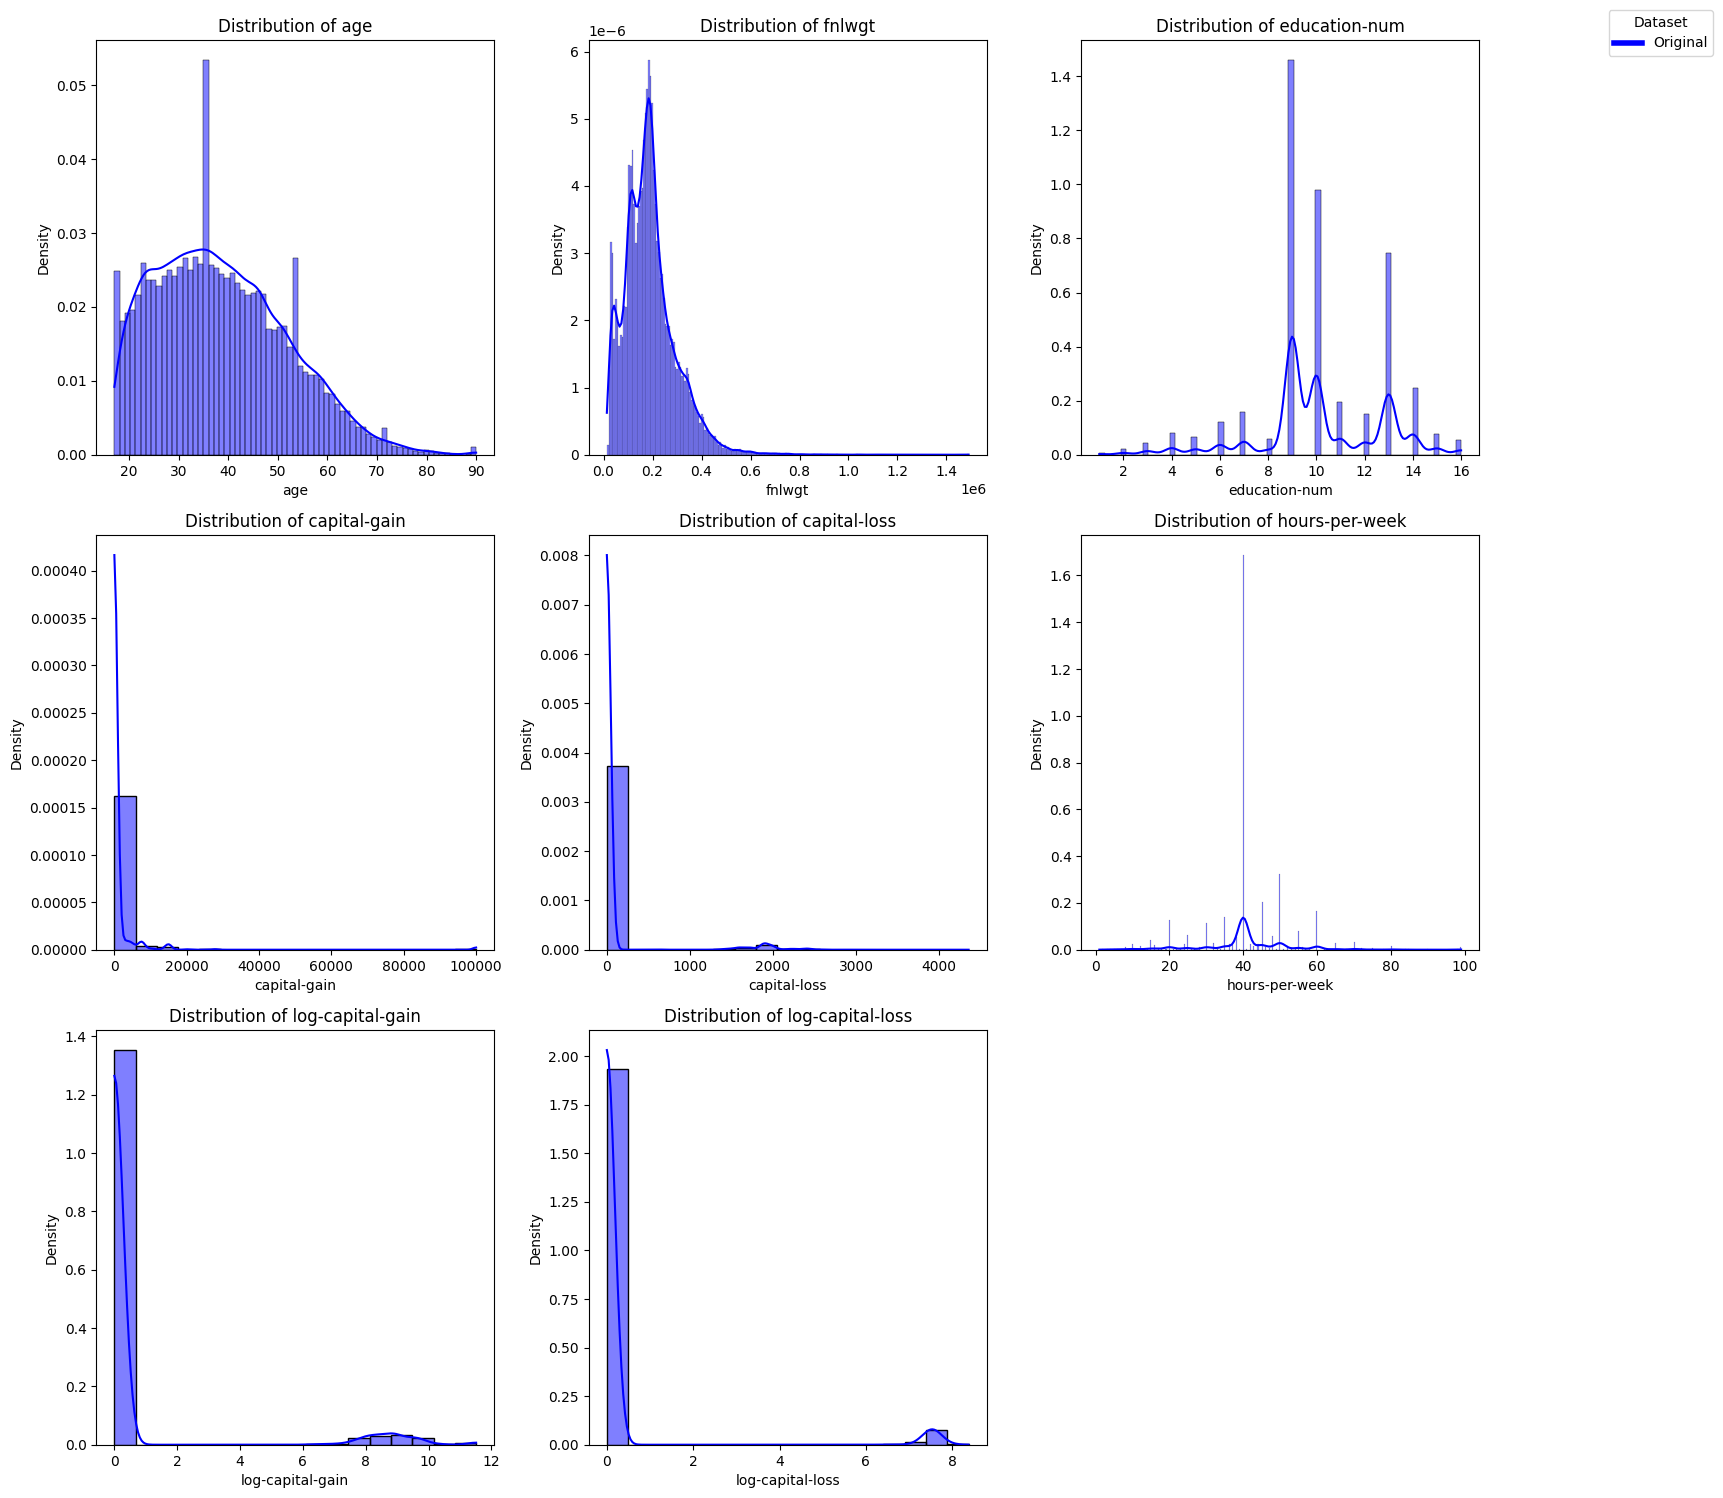

Comparing Hist Plots:


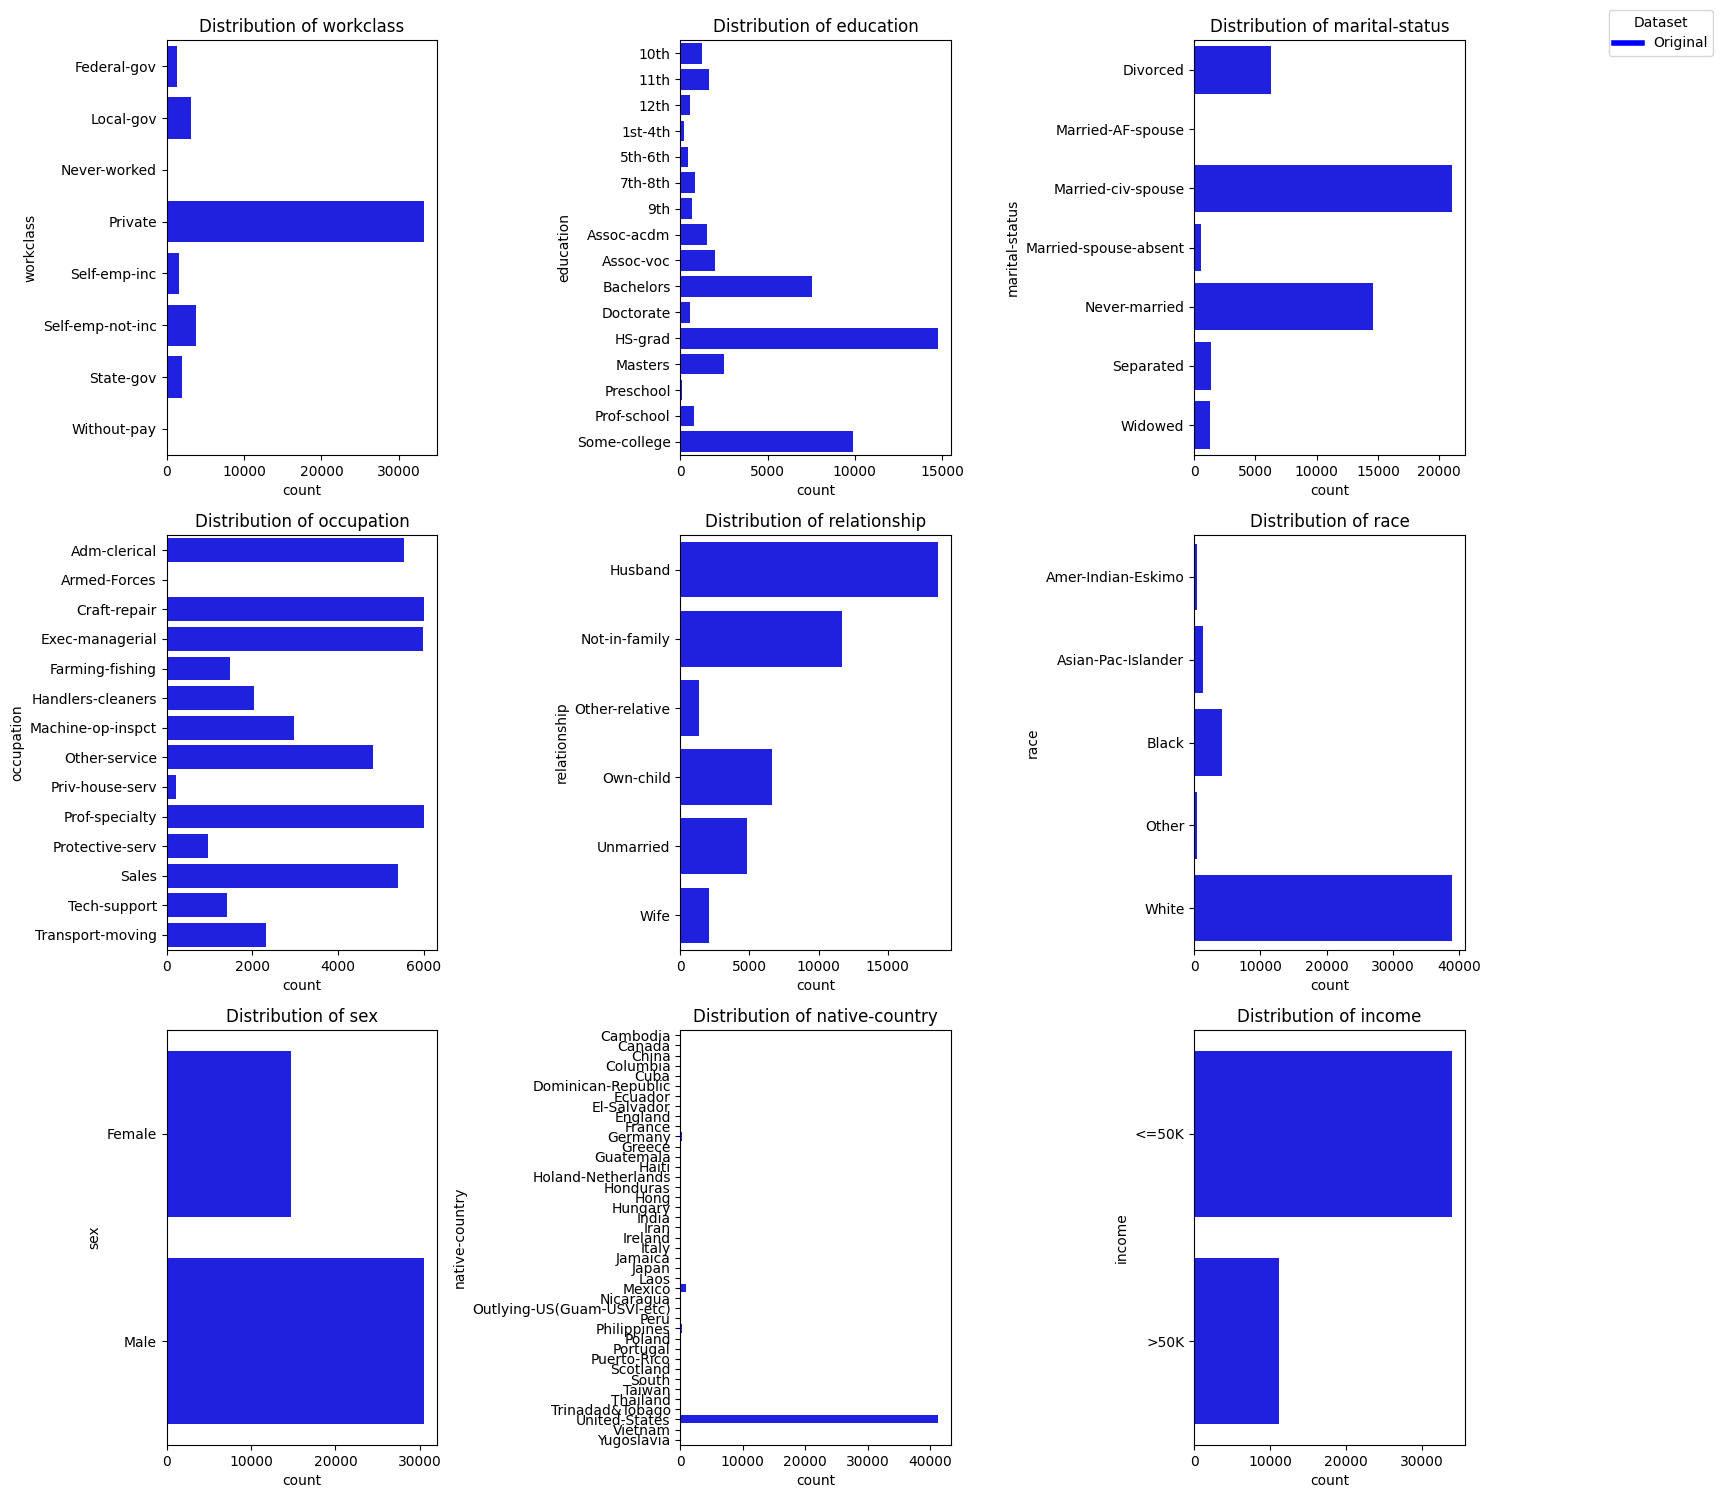

Correlations
Pearson Correlation for Numerical Features:


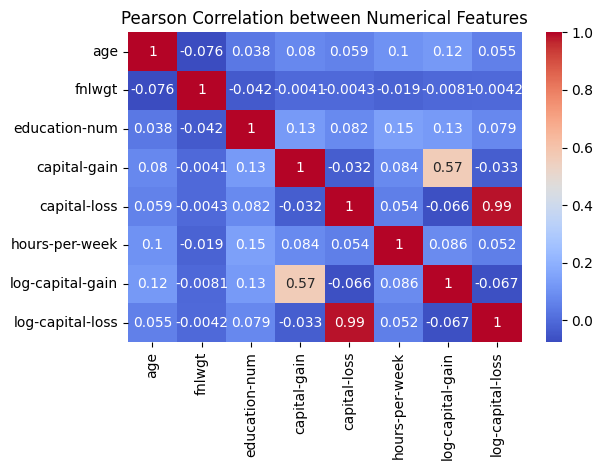

Spearman Correlation for Numerical Features:


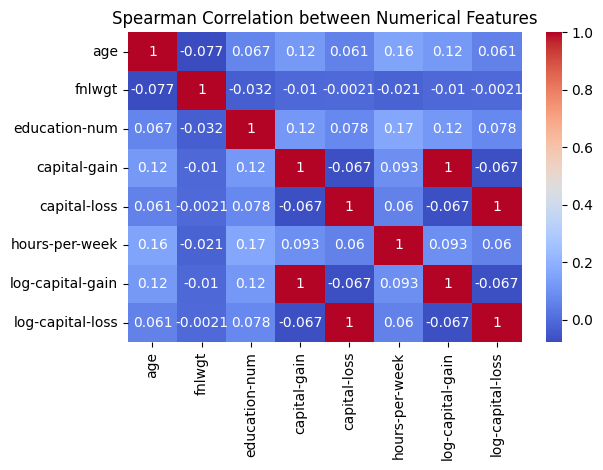

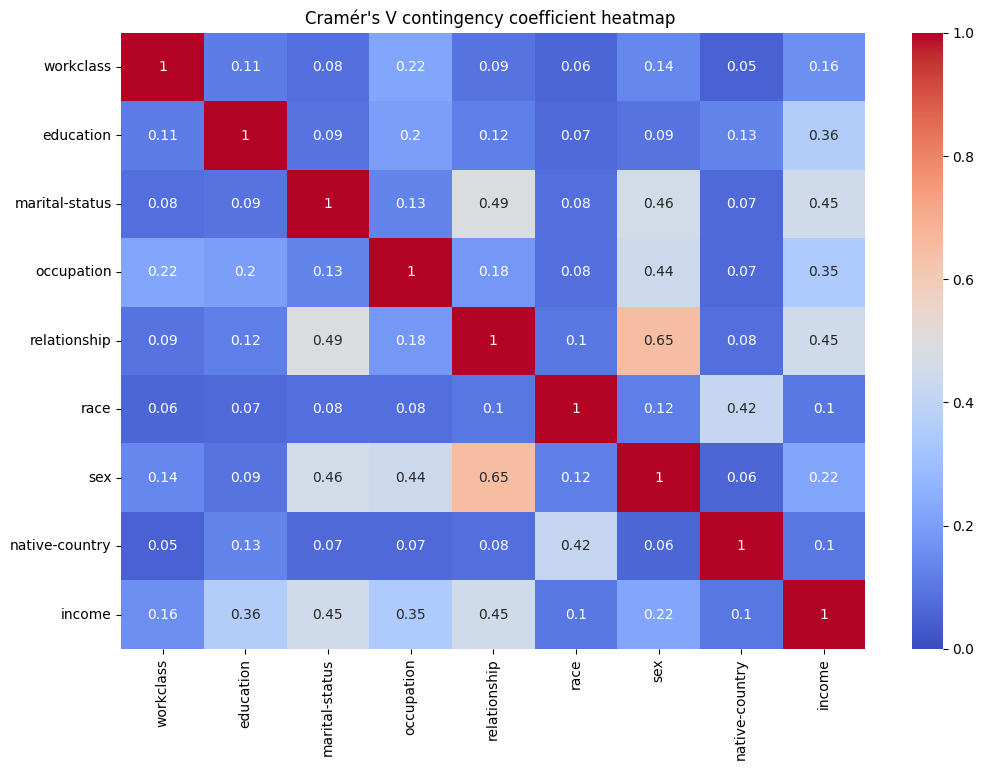

Pair Plot for Numerical Features:


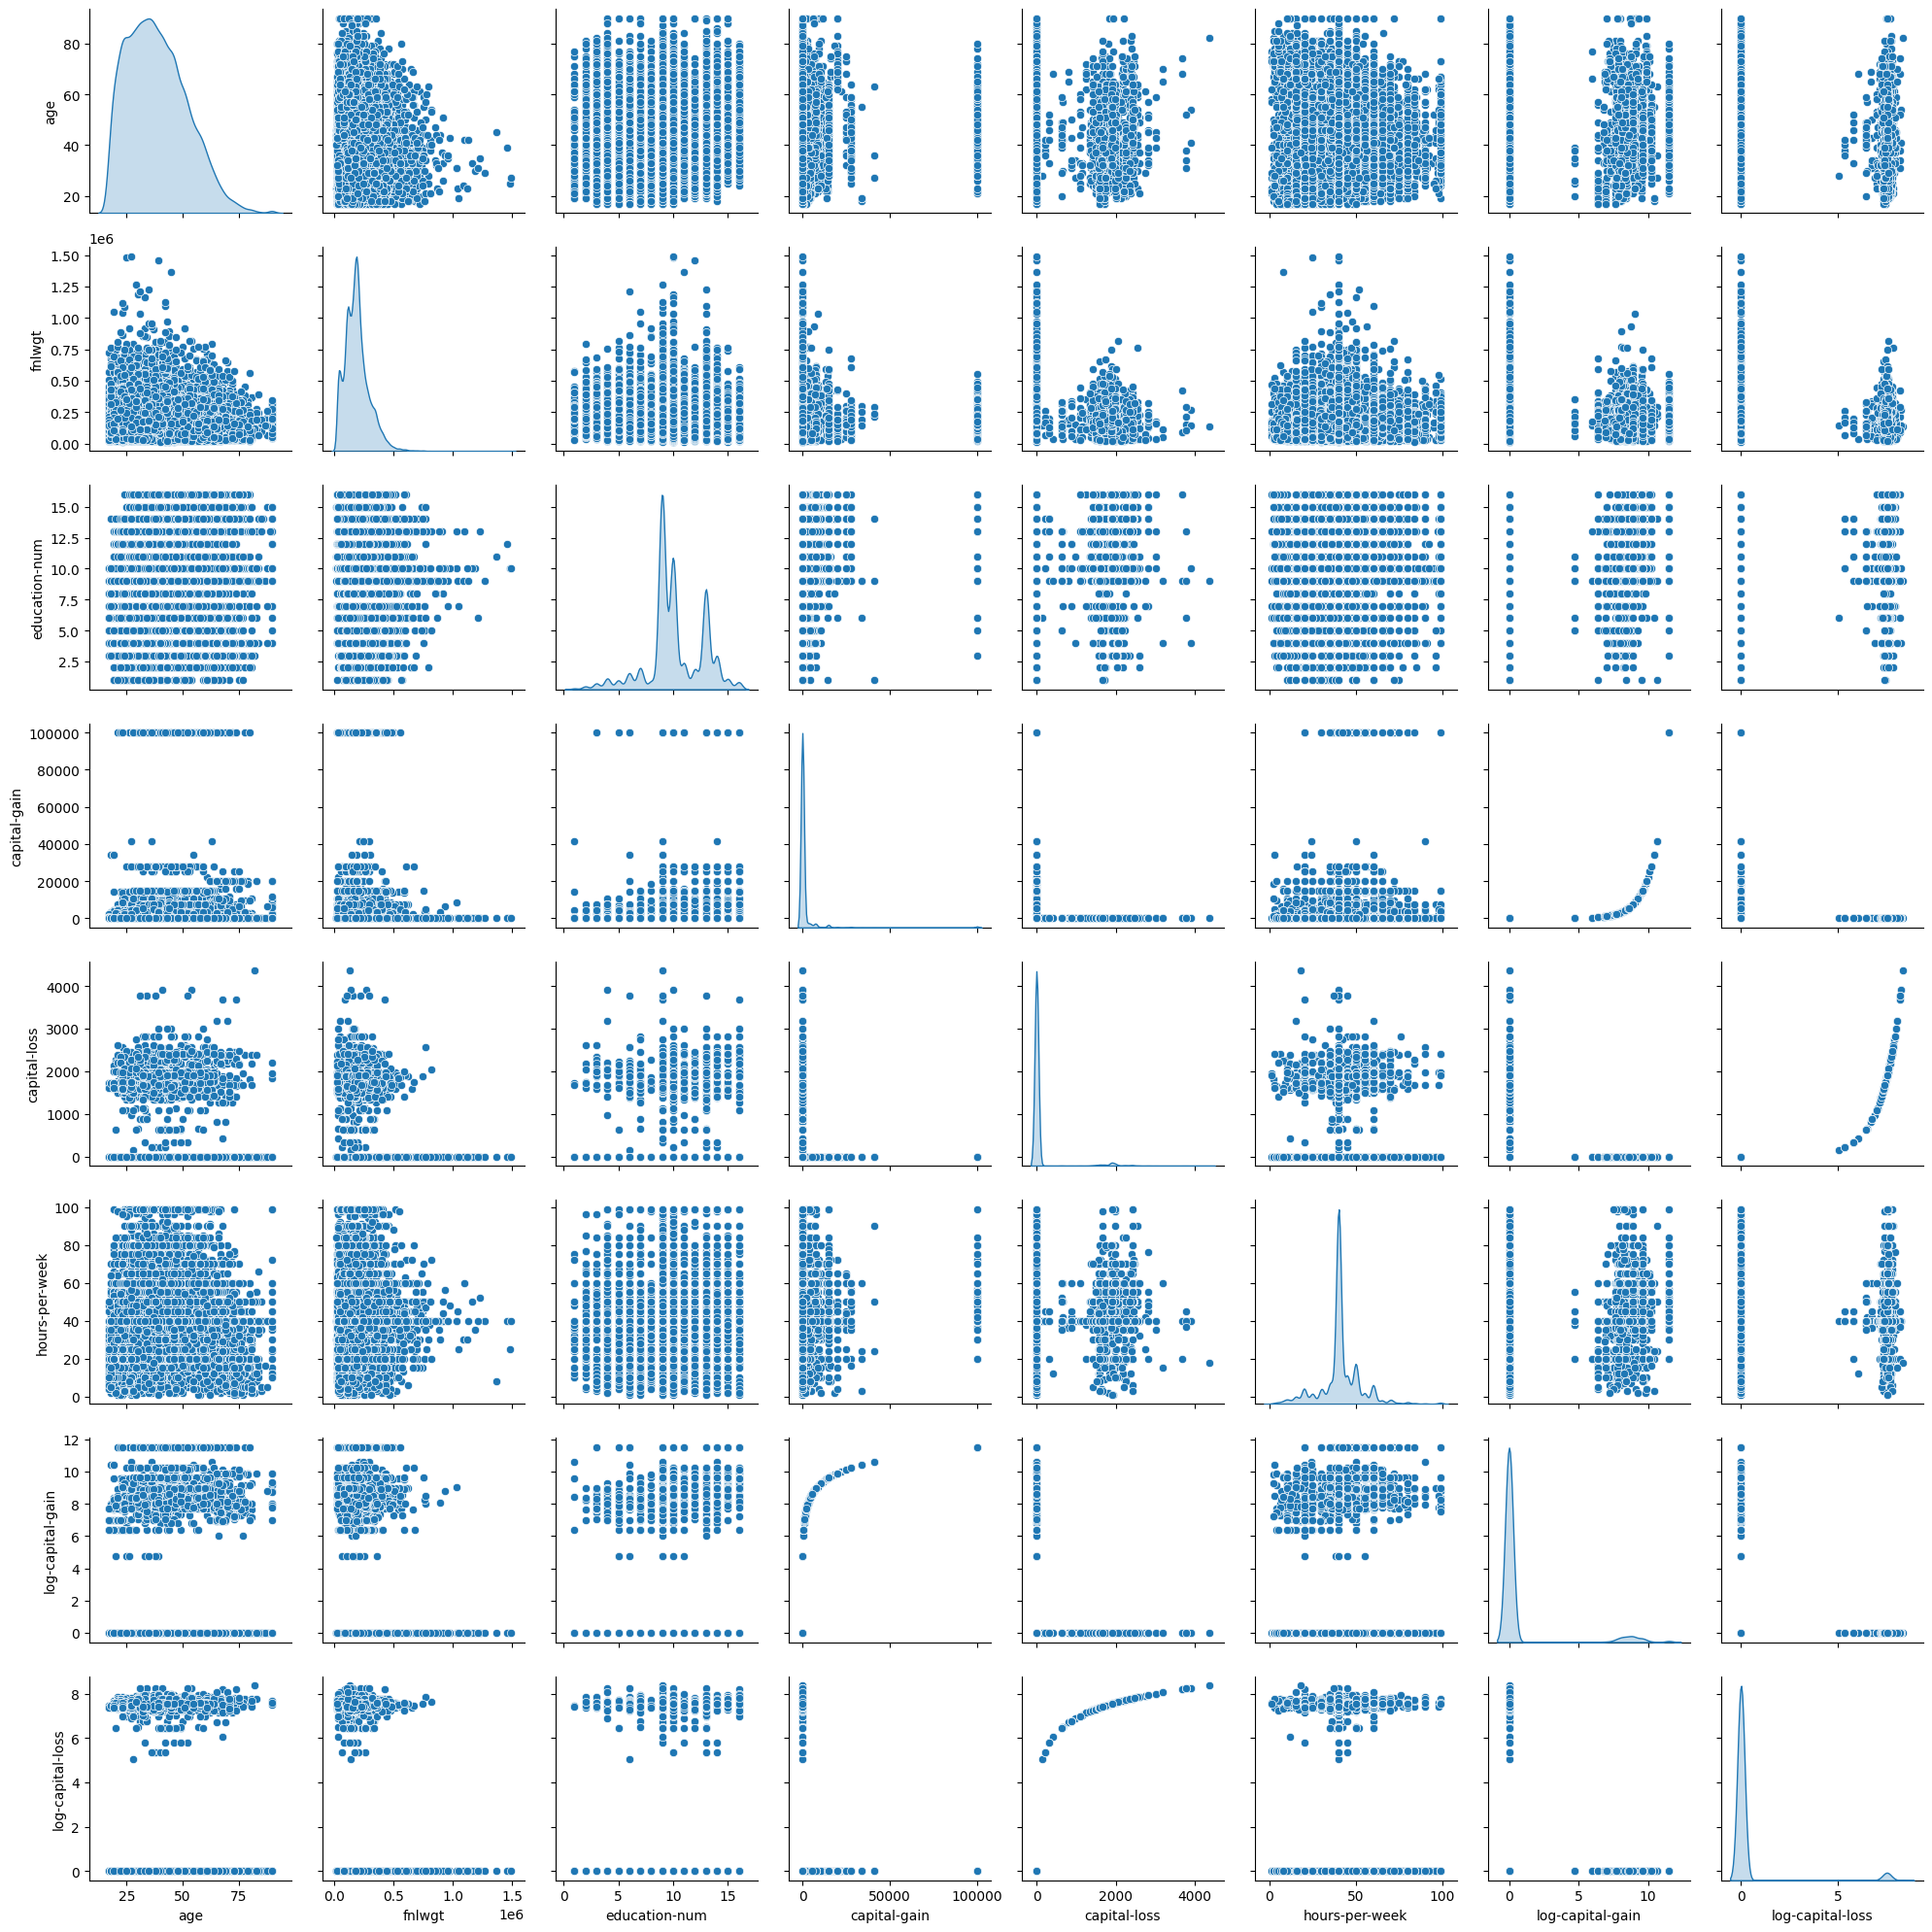

Analysis completed!


In [ ]:
%matplotlib inline
from tools.features_analysis import *

# let's try to add some new features based on the logarithm
run_analysis(adults, numerical_features=numerical_columns, categorical_features=categorical_columns, is_cat_vs_num=False)